# 🌍💹 NOTEBOOK DE RYAN LE MACROECONOMISTE 	🌍💹

## === GUIDE des fonctions du module local datalake === 

from DATALAKE.data import *

**data = data_download_gmd("country")** -> Telechargement des données liés à un pays via global_macro_dataset (BD publique)
**data = data_download_fred("indicator"** : str, "start" : str , "end" : str) -> Telechargement d'un indicateur via la FRED (BD publique)

**data_storing(data : dataframe, "nom_fichier" : str)** -> Range un dataframe "data" dans le DATALAKE en parquet, que vous venez de télécharger d'internet 

**data = import_parquet("file_name" : str)** -> importe un dataframe du DATALAKE dans votre file cible (notebook ou .py)

**which_parquet()** -> Vous renvoie une liste de l'ensemble des parquets dispo dans le DATALAKE

## === Pour importer les fonctions du fichier "outils_eda", si vous en avez besoin lors de votre analyse ===

import sys
import os

sys.path.append("../dorian_code") -> permet à Python d'aller lire les fichiers présent dans le dossier "dorian_code"

from outils_eda import * -> importe le fichier "outils_eda" dont ces fonctions que vous pouvez utiliser lors de l'analyse !

In [51]:
#Dans cette cell j'importe tous les modules dont j'ai besoin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

In [52]:
#Dans cette cell je prends connaisance des données et des différentes variables, elle me sert à me situer
import pandas as pd
path_parquet_file = '/Users/Ryan/economic_research/DATALAKE/PARQUET_FOLDER/main_detrended.parquet'
df_detrended = pd.read_parquet(path_parquet_file)
# Donne un résumé technique du DataFrame
df_detrended.info()
# Statistiques descriptives de base
df_detrended['output_gap'].describe()

# Ou juste mean et std
print(df_detrended['output_gap'].mean())
print(df_detrended['output_gap'].std())



<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 12 to 174
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  105 non-null    float64
 1   gdp_nominal           105 non-null    float64
 2   expected_inflation    105 non-null    float64
 3   taux_changes          105 non-null    float64
 4   cpi                   105 non-null    float64
 5   taux_directeur        105 non-null    float64
 6   export                105 non-null    float64
 7   import                105 non-null    float64
 8   yield_perpetual       105 non-null    float64
 9   oil_price             105 non-null    float64
 10  gdp_cycle             105 non-null    float64
 11  gdp_trend             105 non-null    float64
 12  output_gap            105 non-null    float64
 13  taux_changes_stat     105 non-null    float64
 14  yield_perpetual_stat  105 non-null    float64
 15  gdp_nominal_stat      105 n

In [ ]:
# Statistiques descriptives de base
df_detrended['output_gap'].describe()

# Ou juste mean et std
print(df_detrended['output_gap'].mean())
print(df_detrended['output_gap'].std())
print(df_detrended['output_gap'])


23.628212847613245
985.275308845479
12      -22.973469
13       94.847245
14       33.020206
15      102.844247
16      101.254027
          ...     
168     -64.430063
169    8589.403459
170      69.434407
173      66.259653
174      21.140061
Name: output_gap, Length: 105, dtype: float64


In [54]:
#Le problème avec un modèle VAR est qu'il est impossible d'isoler l'effet d'un choc pur de politique monétaire, car toute les variables interagissent. 
#simultanément. Ainsi, pour passer d'un modèle VAR à SVAR on utilise la décomposition de Cholesky. L'objectif est de classer les variables de la plus 
#lente à réagir à la plus rapide.
variables_svar = ['oil_price_stat', 'output_gap', 'cpi_stat', 'taux_directeur', 'taux_changes_stat']

# Découpage temporel et appliquation de la matrice de Cholesky
df_gold = df_detrended[df_detrended['year'] < 1914].set_index('year')[variables_svar]
df_bw = df_detrended[(df_detrended['year'] >= 1945) & (df_detrended['year'] <= 1973)].set_index('year')[variables_svar]
df_float = df_detrended[df_detrended['year'] > 1973].set_index('year')[variables_svar]

display(df_gold)

,oil_price_stat,output_gap,cpi_stat,taux_directeur,taux_changes_stat
year,,,,,
1862.0,0.762139,-22.973469,-0.026344,3.0,0.78500
1863.0,1.098612,94.847245,-0.036664,7.0,1.51650
1864.0,0.939511,33.020206,-0.009041,6.0,2.89975
1865.0,-0.201360,102.844247,0.008960,7.0,-2.28275
1866.0,-0.566468,101.254027,0.062975,3.5,-0.81475
1869.0,0.002751,-17.914729,-0.051293,3.0,-0.34450
1870.0,0.058683,-48.698207,0.000000,2.5,-0.89500
1871.0,0.117207,45.235233,0.013903,3.0,-0.12800
1872.0,-0.175891,18.833091,0.045929,5.0,-0.01550


  SÉLECTION DU NOMBRE DE LAGS PAR RÉGIME

  Gold Standard (40 obs)  |  maxlags testés : 1
  AIC → 0  |  BIC → 0
  Critère retenu : BIC = 1  ✅

  Bretton Woods (19 obs)  |  maxlags testés : 1
  AIC → 1  |  BIC → 1
  Critère retenu : BIC = 1  ✅

  Floating (41 obs)  |  maxlags testés : 1
  AIC → 1  |  BIC → 1
  Critère retenu : AIC = 1  ✅



/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  

  ✅ Sauvegardé : IRF_charts/IRF_oil_price_stat.png


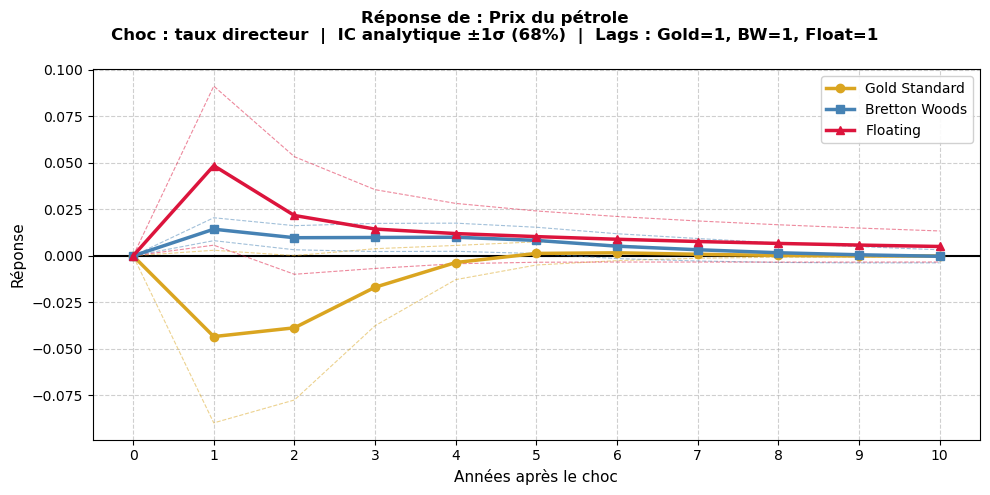

  ✅ Sauvegardé : IRF_charts/IRF_output_gap.png


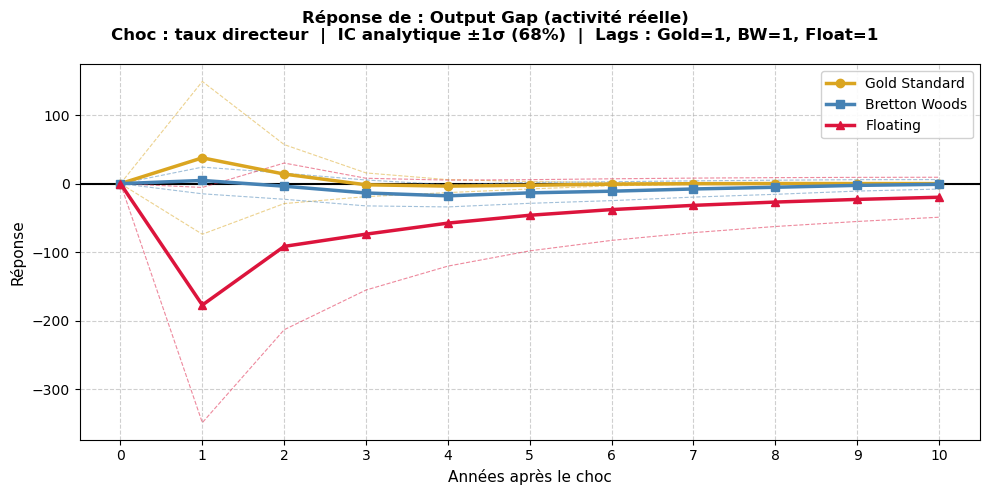

  ✅ Sauvegardé : IRF_charts/IRF_cpi_stat.png


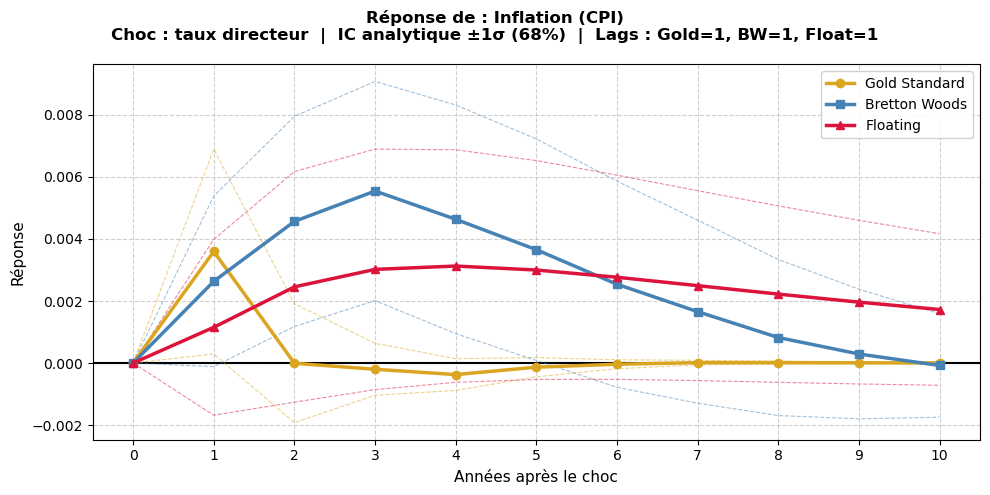

  ✅ Sauvegardé : IRF_charts/IRF_taux_directeur.png


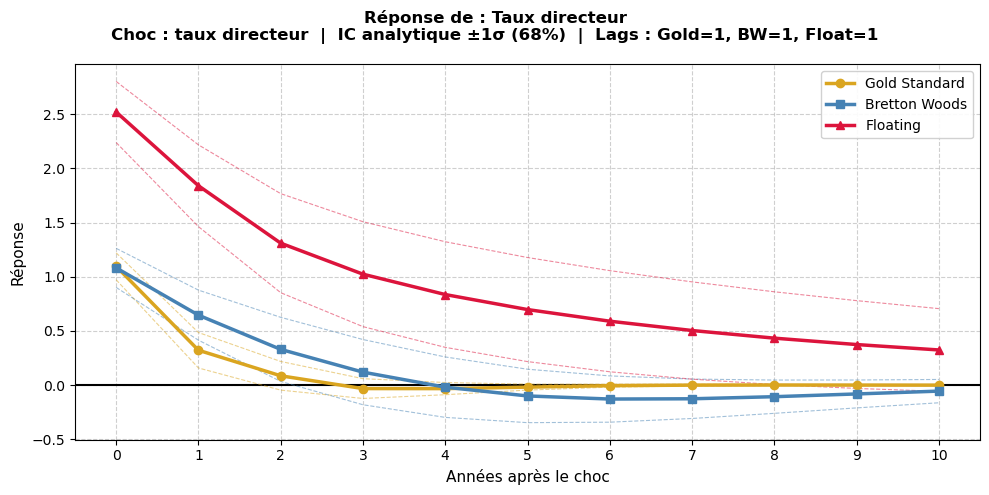

  ✅ Sauvegardé : IRF_charts/IRF_taux_changes_stat.png


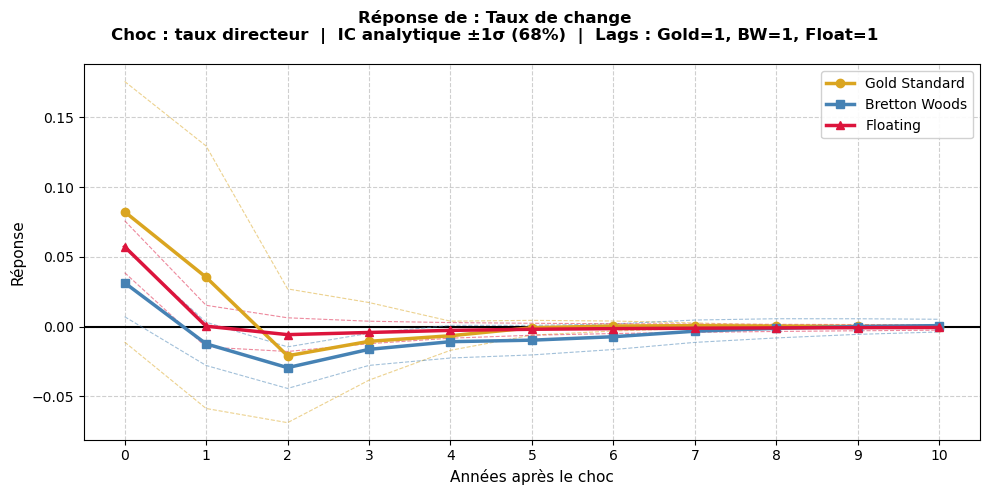


✅ Tous les graphes sont dans le dossier 'IRF_charts/'


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR
import os

# ÉTAPE 1 : ORDRE DE CHOLESKY
# Je garde le même ordre pour les trois régimes :
#   Pétrole → Output → CPI → Taux directeur → Taux de change
#
# L'idée c'est de classer les variables de la plus lente à la plus rapide à
# réagir. Le prix du pétrole est exogène, l'output et l'inflation sont
# rigides à court terme, le taux directeur réagit dans l'année (Taylor),
# et le taux de change ajuste en dernier puisque c'est un prix financier.

variables_svar = ['oil_price_stat', 'output_gap', 'cpi_stat',
                  'taux_directeur', 'taux_changes_stat']

# Je découpe l'échantillon selon les trois régimes de change
df_gold  = df_detrended[df_detrended['year'] < 1914].set_index('year')[variables_svar]
df_bw    = df_detrended[(df_detrended['year'] >= 1945) & (df_detrended['year'] <= 1971)].set_index('year')[variables_svar]
df_float = df_detrended[df_detrended['year'] > 1971].set_index('year')[variables_svar]


# ÉTAPE 2 : CHOIX DU NOMBRE DE LAGS PAR RÉGIME
# J'utilise BIC pour Gold et Bretton Woods (petits échantillons, BIC pénalise
# plus les paramètres) et AIC pour Floating qui a plus d'observations.
print("=" * 60)
print("  SÉLECTION DU NOMBRE DE LAGS PAR RÉGIME")
print("=" * 60)

configs = {
    'Gold Standard': (df_gold,  'bic'),
    'Bretton Woods': (df_bw,    'bic'),
    'Floating':      (df_float, 'aic'),
}

optimal_lags = {}

for name, (df, criterion) in configs.items():
    n_obs = len(df)
    # Je limite le maxlag pour éviter de surparamétriser avec peu d'obs
    maxlags = max(1, min(3, int(n_obs / (5 * len(df.columns)))))
    selection  = VAR(df).select_order(maxlags=maxlags)
    lag_chosen = max(1, getattr(selection, criterion))
    optimal_lags[name] = lag_chosen
    print(f"\n  {name} ({n_obs} obs)  |  maxlags testés : {maxlags}")
    print(f"  AIC → {selection.aic}  |  BIC → {selection.bic}")
    print(f"  Critère retenu : {criterion.upper()} = {lag_chosen}  ✅")

print("\n" + "=" * 60)

# ÉTAPE 3 : ESTIMATION DES TROIS VAR
res_gold  = VAR(df_gold).fit(optimal_lags['Gold Standard'])
res_bw    = VAR(df_bw).fit(optimal_lags['Bretton Woods'])
res_float = VAR(df_float).fit(optimal_lags['Floating'])

# ÉTAPE 4 : FONCTIONS DE RÉPONSE IMPULSIONNELLE (IC à 68%)
# Je trace les IRF sur 10 ans avec un intervalle de confiance analytique
# à ±1 écart-type, soit environ 68%. C'est le standard dans la littérature
# SVAR (un IC à 95% rend les graphes illisibles avec mes petits échantillons).
horizon = 10
Z = 1   # ±1 écart-type → IC à 68%

irf_gold  = res_gold.irf(horizon)
irf_bw    = res_bw.irf(horizon)
irf_float = res_float.irf(horizon)

def get_classic_ci(irf_obj, idx_response, idx_shock):
    """Je récupère la réponse moyenne et son IC à ±1σ"""
    mean  = irf_obj.orth_irfs[:, idx_response, idx_shock]
    se    = irf_obj.stderr(orth=True)[:, idx_response, idx_shock]
    lower = mean - Z * se
    upper = mean + Z * se
    return lower, upper, mean

# ÉTAPE 5 : UN GRAPHE PAR VARIABLE DE RÉPONSE
colors  = {'Gold Standard': 'goldenrod', 'Bretton Woods': 'steelblue', 'Floating': 'crimson'}
markers = {'Gold Standard': 'o',         'Bretton Woods': 's',         'Floating': '^'}

# Noms lisibles pour les titres
display_names = {
    'oil_price_stat':    'Prix du pétrole',
    'output_gap':        'Output Gap (activité réelle)',
    'cpi_stat':          'Inflation (CPI)',
    'taux_directeur':    'Taux directeur',
    'taux_changes_stat': 'Taux de change',
}

folder = 'IRF_charts'
os.makedirs(folder, exist_ok=True)

x_axis = range(horizon + 1)

# L'indice du choc est le même pour les trois régimes vu que l'ordre est unifié
idx_shock = variables_svar.index('taux_directeur')

for var_response in variables_svar:

    idx_rep = variables_svar.index(var_response)

    # Je calcule les IC pour les trois régimes
    lower_gold,  upper_gold,  val_gold  = get_classic_ci(irf_gold,  idx_rep, idx_shock)
    lower_bw,    upper_bw,    val_bw    = get_classic_ci(irf_bw,    idx_rep, idx_shock)
    lower_float, upper_float, val_float = get_classic_ci(irf_float, idx_rep, idx_shock)

    # Mise en place du graphe
    fig, ax = plt.subplots(figsize=(10, 5))

    readable_name = display_names.get(var_response, var_response)

    fig.suptitle(
        f"Réponse de : {readable_name}\n"
        f"Choc : taux directeur  |  IC analytique ±1σ (68%)  |  "
        f"Lags : Gold={optimal_lags['Gold Standard']}, "
        f"BW={optimal_lags['Bretton Woods']}, "
        f"Float={optimal_lags['Floating']}",
        fontsize=12, fontweight='bold'
    )

    # Ligne du zéro pour repérer le sens des réponses
    ax.axhline(0, color='black', linewidth=1.5)

    # Je trace les bornes des IC en pointillés (plus discret que des bandes)
    ax.plot(lower_gold,  color=colors['Gold Standard'], linestyle='--', linewidth=0.8, alpha=0.5)
    ax.plot(upper_gold,  color=colors['Gold Standard'], linestyle='--', linewidth=0.8, alpha=0.5)
    ax.plot(lower_bw,    color=colors['Bretton Woods'], linestyle='--', linewidth=0.8, alpha=0.5)
    ax.plot(upper_bw,    color=colors['Bretton Woods'], linestyle='--', linewidth=0.8, alpha=0.5)
    ax.plot(lower_float, color=colors['Floating'],      linestyle='--', linewidth=0.8, alpha=0.5)
    ax.plot(upper_float, color=colors['Floating'],      linestyle='--', linewidth=0.8, alpha=0.5)

    # Les courbes principales des IRF
    ax.plot(val_gold,  label='Gold Standard', color=colors['Gold Standard'],
            linewidth=2.5, marker=markers['Gold Standard'], markersize=6)
    ax.plot(val_bw,    label='Bretton Woods', color=colors['Bretton Woods'],
            linewidth=2.5, marker=markers['Bretton Woods'], markersize=6)
    ax.plot(val_float, label='Floating',      color=colors['Floating'],
            linewidth=2.5, marker=markers['Floating'],      markersize=6)

    # Habillage
    ax.set_xlabel("Années après le choc", fontsize=11)
    ax.set_ylabel("Réponse", fontsize=11)
    ax.set_xticks(range(0, horizon + 1))
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

    plt.tight_layout()

    # Je sauvegarde chaque graphe en PNG
    file_name = f"{folder}/IRF_{var_response}.png"
    plt.savefig(file_name, dpi=150, bbox_inches='tight')
    print(f"  ✅ Sauvegardé : {file_name}")

    plt.show()
    plt.close(fig)

print(f"\n✅ Tous les graphes sont dans le dossier '{folder}/'")